#Dataset Overview

#Import Data and Libraries

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import torch.optim as optim

In [ ]:
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True, num_workers=2)

evalset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
evalloader = torch.utils.data.DataLoader(evalset, batch_size=128,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:04<00:00, 40.5MB/s]


##Exploration Data Analysis

##Dataset distribution

In [ ]:
def get_distribution(dataset):
    labels = dataset.labels.squeeze()
    unique, counts = np.unique(labels, return_counts=True)
    return counts

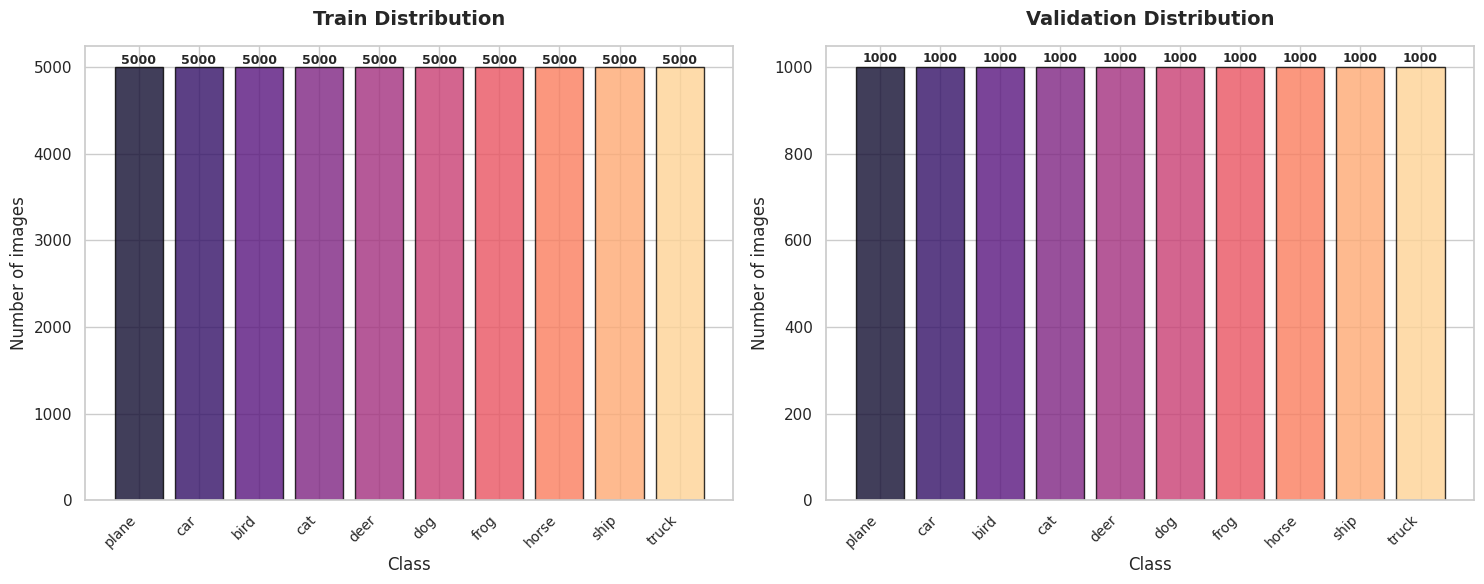

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

def get_distribution(dataset):
    counts = Counter(dataset.targets)
    return [counts[i] for i in range(10)]

train_counts = get_distribution(trainset)
val_counts = get_distribution(evalset)

class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

colors = sns.color_palette("magma", len(class_names))
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 6))

def plot_styled_bar(subplot_pos, counts, title, colors):
    plt.subplot(1, 2, subplot_pos)
    bars = plt.bar(class_names, counts, color=colors, edgecolor='black', alpha=0.8)

    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("Number of images", fontsize=12)
    plt.xlabel("Class", fontsize=12)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                 f'{int(height)}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

plot_styled_bar(1, train_counts, "Train Distribution", colors)
plot_styled_bar(2, val_counts, "Validation Distribution", colors)

plt.tight_layout()
plt.show()

#Part 1: Build Classification Model

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

##Softmax Regression

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SoftmaxRegression(nn.Module):
    def __init__(self):
        super(SoftmaxRegression, self).__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(3072, 10)

    def forward(self, x):
        x = self.flatten(x)
        outputs = self.linear(x)
        return outputs

model_softmax = SoftmaxRegression()
print(model_softmax)

SoftmaxRegression(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=3072, out_features=10, bias=True)
)


##MLP

In [ ]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 512),nn.ReLU(),
            nn.Linear(512, 256),nn.ReLU(),
            nn.Linear(256, 10))

    def forward(self, x):
        return self.network(x)

model_MLP = MLP()
print(model_MLP)

MLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)


##CNN based

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = x.view(-1, 64 * 8 * 8) # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model_CNN = SimpleCNN()

##ViT model (Build - in)

In [ ]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels, embed_dim, img_size=32, patch_size=4):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class VisionTransformerBuiltIn(nn.Module):
    def __init__(self, in_channels=3, num_classes=10, img_size=32, patch_size=4,
                 embed_dim=256, depth=6, n_heads=8, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels, embed_dim, img_size, patch_size)
        num_patches = self.patch_embed.n_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)
        x = self.encoder(x)
        return self.head(self.norm(x[:, 0]))

model_ViT_CustomBuiltIn = VisionTransformerBuiltIn(
    in_channels=3,
    num_classes=10,
    img_size=32,
    patch_size=4
).to(device)

#Part 2: Training, Evaluatation, and Comparison

In [ ]:
def train_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer, accuracy_fn, device: torch.device = device):
    train_loss, train_acc = 0, 0
    y_true_all, y_pred_all = [], []

    model.train()
    model.to(device)

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        y = torch.as_tensor(y).squeeze().long()

        y_logits = model(X)
        y_pred = y_logits.argmax(dim=1)

        loss = loss_fn(y_logits, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred)

        y_true_all.extend(y.cpu().numpy())
        y_pred_all.extend(y_pred.cpu().numpy())

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)

    precision, recall, f1, _ = precision_recall_fscore_support(y_true_all, y_pred_all, average='macro', zero_division=0)

    return train_loss, train_acc, precision*100, recall*100, f1*100

In [ ]:
def eval_func(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):

    eval_loss, eval_acc = 0, 0
    model.to(device)
    model.eval()

    y_preds = []
    y_targets = []

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y = torch.as_tensor(y).squeeze().long()

            eval_logits = model(X)

            eval_loss += loss_fn(eval_logits, y).item()
            current_batch_preds = eval_logits.argmax(dim=1)
            eval_acc += accuracy_fn(y_true=y, y_pred=current_batch_preds)

            y_preds.append(current_batch_preds)
            y_targets.append(y)

    eval_loss /= len(data_loader)
    eval_acc /= len(data_loader)

    y_preds_tensor = torch.cat(y_preds).cpu()
    y_targets_tensor = torch.cat(y_targets).cpu()

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_targets_tensor.numpy(),
        y_preds_tensor.numpy(),
        average='macro',
        zero_division=0
    )

    return {
        "model_name": model.__class__.__name__,
        "loss": eval_loss,
        "accuracy": eval_acc,
        "precision": precision * 100,
        "recall": recall * 100,
        "f1": f1 * 100,
        "predictions": y_preds_tensor,
        "targets": y_targets_tensor
    }

##Training

In [ ]:
def run_benchmarks(models_dict, train_loader, eval_loader, loss_fn, accuracy_fn, device, epochs=5):
    all_final_results = []
    all_histories = {}

    for model_name, model in models_dict.items():
        print("\n" + "="*140)
        print(f"{'MÔ HÌNH:':<15} {model_name}")
        print("="*140)

        optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        model.to(device)

        history = {"train_loss": [], "train_acc": [], "eval_loss": [], "eval_acc": [], "time": []}

        header = f"{'Epoch':^6} | {'Train (L / A% / P% / R% / F1%)':^45} | {'Eval (L / A% / P% / R% / F1%)':^45} | {'Time':^8}"
        print(header)
        print("-" * len(header))

        start_time_total = time.time()

        for epoch in range(epochs):
            start_time_epoch = time.time()

            model.train()
            t_l, t_a, t_p, t_r, t_f1 = train_step(model, train_loader, loss_fn, optimizer, accuracy_fn, device)

            model.eval()
            with torch.inference_mode():
                ev_res = eval_func(eval_loader, model, loss_fn, accuracy_fn, device)
                ev_l, ev_a, ev_p, ev_r, ev_f1 = ev_res["loss"], ev_res["accuracy"], ev_res["precision"], ev_res["recall"], ev_res["f1"]

            epoch_duration = time.time() - start_time_epoch

            history["train_loss"].append(t_l)
            history["train_acc"].append(t_a)
            history["eval_loss"].append(ev_l)
            history["eval_acc"].append(ev_a)
            history["time"].append(epoch_duration)

            def fmt(l, a, p, r, f):
                return f"{l:.3f} / {a:>5.1f}% / {p:>5.1f}% / {r:>5.1f}% / {f:>5.1f}%"

            print(f"{epoch+1:^6} | {fmt(t_l, t_a, t_p, t_r, t_f1):<45} | {fmt(ev_l, ev_a, ev_p, ev_r, ev_f1):<45} | {epoch_duration:>7.2f}s")

        all_histories[model_name] = history
        total_time = time.time() - start_time_total
        all_final_results.append({
            "Model": model_name,
            "Final Eval Acc": ev_a,
            "Final Eval F1": ev_f1,
            "Total Time (s)": total_time
        })
        print("="*140)

    return all_final_results, all_histories

In [ ]:
models_to_test = {
    "Softmax_Baseline": model_softmax,
    "MLP": model_MLP,
    "Simple_CNN": model_CNN,
    "ViT_BuiltIn": model_ViT_CustomBuiltIn
}
loss_fn = nn.CrossEntropyLoss()

def accuracy_fn(y_true, y_pred):
    return (torch.eq(y_true, y_pred).sum().item() / len(y_pred)) * 100

In [ ]:
import matplotlib.pyplot as plt

def plot_training_results(histories):
    """
    histories: Dictionary chứa kết quả của từng model
    Ví dụ: histories['Softmax'] = {'train_loss': [...], 'eval_acc': [...], ...}
    """
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    for model_name, metrics in histories.items():
        epochs = range(1, len(metrics['train_loss']) + 1)
        plt.plot(epochs, metrics['train_loss'], label=f'{model_name} (Train)', linestyle='--')
        plt.plot(epochs, metrics['eval_loss'], label=f'{model_name} (Eval)', linewidth=2)

    plt.title('Training & Evaluation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.subplot(1, 2, 2)
    for model_name, metrics in histories.items():
        epochs = range(1, len(metrics['train_acc']) + 1)
        plt.plot(epochs, metrics['train_acc'], label=f'{model_name} (Train)', linestyle='--')
        plt.plot(epochs, metrics['eval_acc'], label=f'{model_name} (Eval)', linewidth=2)

    plt.title('Training & Evaluation Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [ ]:
print("BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ...")

final_results_trad, histories_trad = run_benchmarks(
    models_dict=models_to_test,
    train_loader=trainloader,
    eval_loader=evalloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device,
    epochs=10)

BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ...

MÔ HÌNH:        Softmax_Baseline
Epoch  |        Train (L / A% / P% / R% / F1%)         |         Eval (L / A% / P% / R% / F1%)         |   Time  
-----------------------------------------------------------------------------------------------------------------
  1    | 1.840 /  36.6% /  36.1% /  36.6% /  35.7%     | 1.769 /  38.9% /  38.6% /  39.1% /  38.6%     |   15.13s
  2    | 1.756 /  40.2% /  39.6% /  40.2% /  39.4%     | 1.756 /  39.0% /  39.1% /  39.3% /  38.7%     |   15.18s
  3    | 1.730 /  41.1% /  40.5% /  41.1% /  40.4%     | 1.738 /  40.4% /  39.7% /  40.3% /  39.5%     |   14.33s
  4    | 1.714 /  41.7% /  41.0% /  41.7% /  41.0%     | 1.732 /  40.0% /  40.0% /  40.3% /  39.8%     |   15.01s
  5    | 1.702 /  42.2% /  41.6% /  42.2% /  41.6%     | 1.723 /  40.2% /  40.1% /  40.4% /  40.0%     |   15.44s
  6    | 1.694 /  42.5% /  41.9% /  42.5% /  42.0%     | 1.723 /  40.4% /  40.1% /  40.6% /  40.0%     |   14.92s
  7    | 1

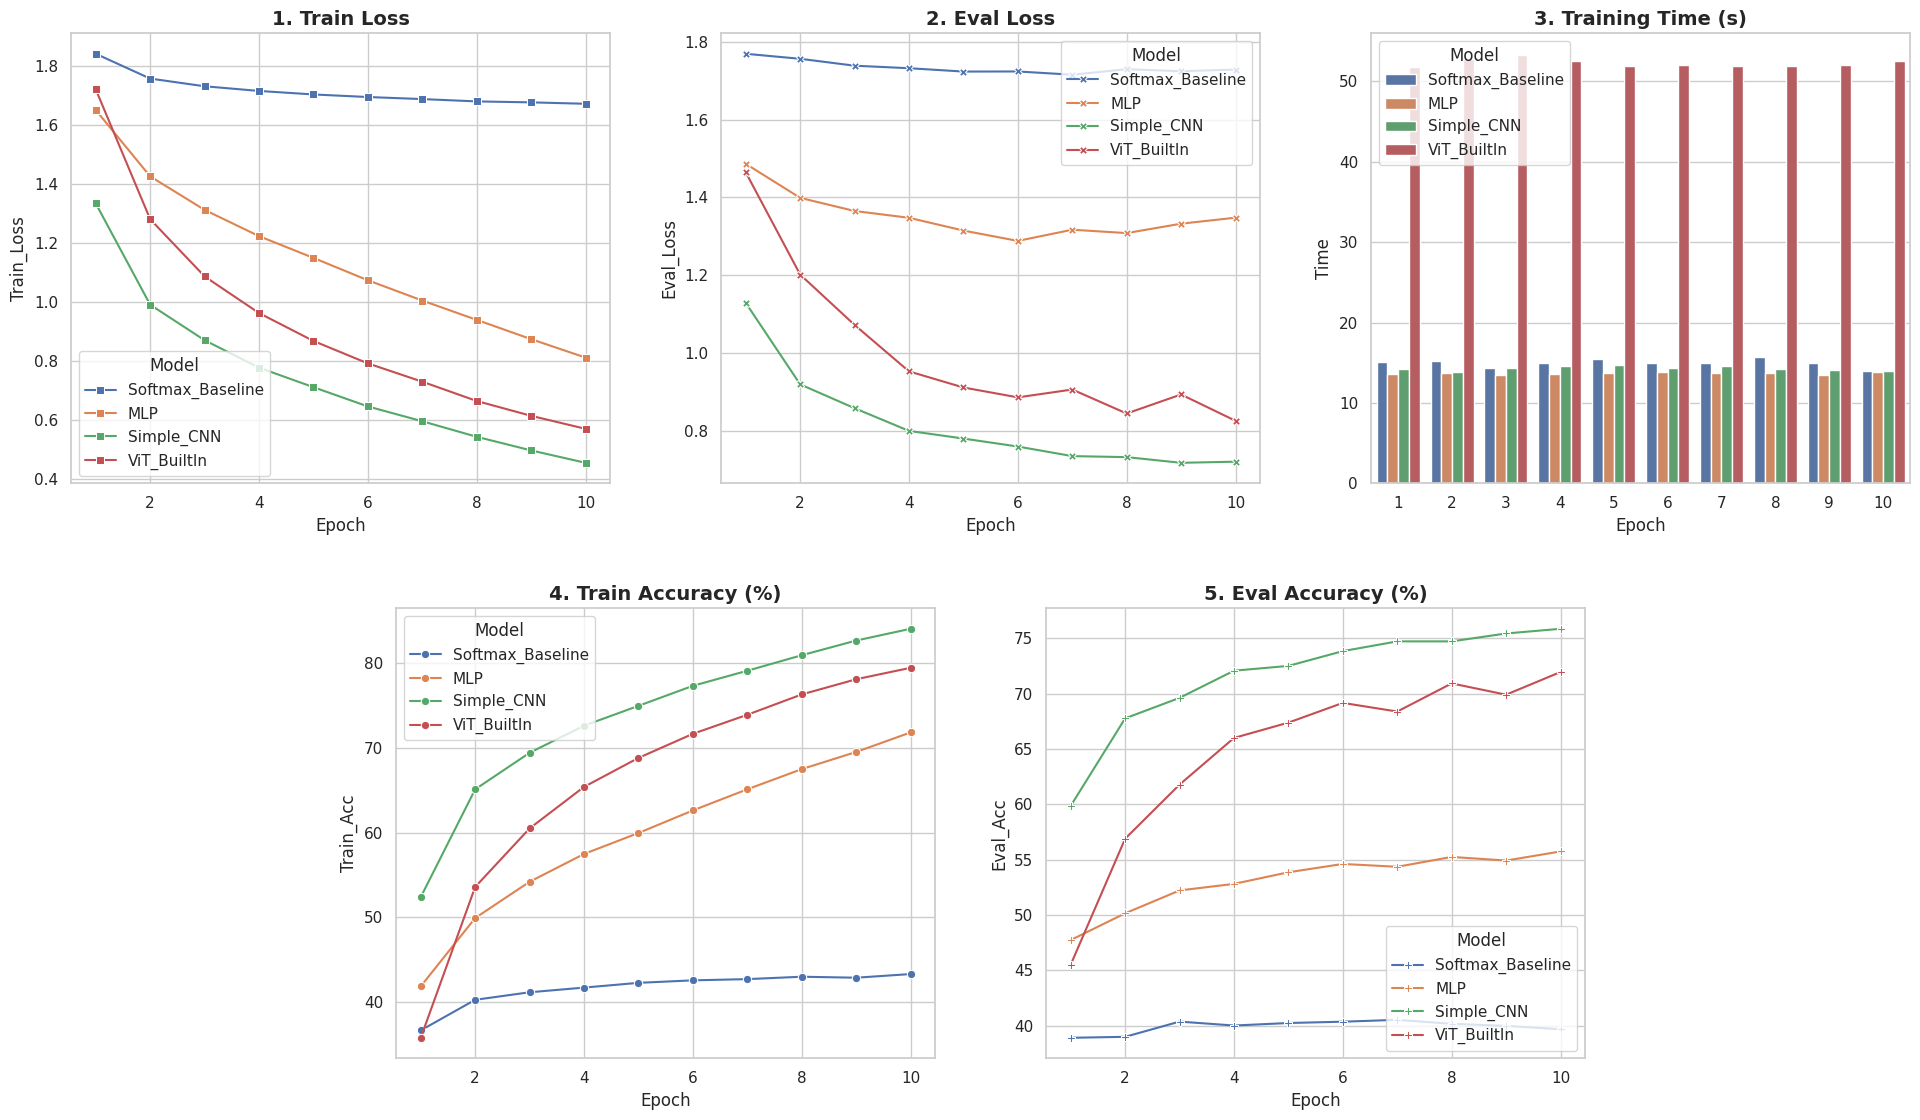

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_5_comparison_charts(histories):
    all_data = []

    for model_name, history in histories.items():
        num_epochs = len(history["train_loss"])
        for i in range(num_epochs):
            all_data.append({
                'Epoch': i + 1,
                'Train_Loss': history["train_loss"][i],
                'Train_Acc': history["train_acc"][i],
                'Eval_Loss': history["eval_loss"][i],
                'Eval_Acc': history["eval_acc"][i],
                'Time': history["time"][i],
                'Model': model_name
            })

    df = pd.DataFrame(all_data)

    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(20, 12))

    ax1 = plt.subplot2grid((2, 6), (0, 0), colspan=2)
    ax2 = plt.subplot2grid((2, 6), (0, 2), colspan=2)
    ax3 = plt.subplot2grid((2, 6), (0, 4), colspan=2)

    ax4 = plt.subplot2grid((2, 6), (1, 1), colspan=2)
    ax5 = plt.subplot2grid((2, 6), (1, 3), colspan=2)

    sns.lineplot(ax=ax1, data=df, x='Epoch', y='Train_Loss', hue='Model', marker='s')
    ax1.set_title('1. Train Loss', fontsize=14, fontweight='bold')

    sns.lineplot(ax=ax2, data=df, x='Epoch', y='Eval_Loss', hue='Model', marker='X')
    ax2.set_title('2. Eval Loss', fontsize=14, fontweight='bold')

    sns.barplot(ax=ax3, data=df, x='Epoch', y='Time', hue='Model')
    ax3.set_title('3. Training Time (s)', fontsize=14, fontweight='bold')

    sns.lineplot(ax=ax4, data=df, x='Epoch', y='Train_Acc', hue='Model', marker='o')
    ax4.set_title('4. Train Accuracy (%)', fontsize=14, fontweight='bold')

    sns.lineplot(ax=ax5, data=df, x='Epoch', y='Eval_Acc', hue='Model', marker='P')
    ax5.set_title('5. Eval Accuracy (%)', fontsize=14, fontweight='bold')

    plt.tight_layout(pad=3.0)
    plt.show()


plot_5_comparison_charts(histories_trad)

# Part 3: Rewritten TransformerEncoder and ViT

## Multi-Head Self Attention, FeedForward, and Encoder Layer (Rewritten)

In [ ]:
import torch
import torch.nn as nn
import copy

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, multi_heads, dropout=0.1):
        super().__init__()

        self.embed_dim = embed_dim
        self.multi_heads = multi_heads
        self.head_dim = embed_dim // multi_heads

        self.WK = nn.Linear(self.embed_dim, self.embed_dim)
        self.WQ = nn.Linear(self.embed_dim, self.embed_dim)
        self.WV = nn.Linear(self.embed_dim, self.embed_dim)
        self.LN = nn.Linear(self.embed_dim, self.embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        H = self.multi_heads
        HD = self.head_dim

        K = self.WK(x)  # (B, N, D) - D = H * HD
        Q = self.WQ(x)
        V = self.WV(x)

        # Reshape (B, N, H, HD) --> Permute (B, H, N, HD)
        K = K.reshape(B, N, H, HD).permute(0, 2, 1, 3)
        Q = Q.reshape(B, N, H, HD).permute(0, 2, 1, 3)
        V = V.reshape(B, N, H, HD).permute(0, 2, 1, 3)

        # C = Q@K^T --> C = C/sqrt(D) --> (B, H, N, N)
        C = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)

        C = torch.softmax(C, dim=-1)

        # Dropout
        C = self.dropout(C)

        # F = C@V
        F = torch.matmul(C, V)  # (B, H, N, HD)

        # Permute (B, N, H, HD) --> Reshape (B, N, D)
        F = F.permute(0, 2, 1, 3).reshape(B, N, self.embed_dim)

        F = self.LN(F)  # (B, N, D)

        return F

class FeedForward(nn.Module):
    def __init__(self, embeb_dim, mlp_ratio=4, dropout=0.1, activation='relu'):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(embeb_dim, int(embeb_dim * mlp_ratio)), # Cast to int
            nn.ReLU() if activation == 'relu' else nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(embeb_dim * mlp_ratio), embeb_dim), # Cast to int
        )

    def forward(self, x):
        return self.net(x)

class MyEncoderLayer(nn.Module):
    def __init__(self,
                 embed_dim,
                 multi_heads,
                 mlp_ratio=4.0,
                 dropout=0.1,
                 activation='relu',
                 norm_first=False
                 ):
        super().__init__()

        self.attn = MultiHeadSelfAttention(embed_dim, multi_heads, dropout)
        self.ffn = FeedForward(embed_dim, mlp_ratio, dropout, activation)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.norm_first = norm_first

    def forward(self, x):
        if self.norm_first:
            attn_output = x + self.dropout1(self.attn(self.norm1(x)))
            ffn_output = attn_output + self.dropout2(self.ffn(self.norm2(attn_output)))
        else:
            attn_output = self.norm1(x + self.dropout1(self.attn(x)))
            ffn_output = self.norm2(attn_output + self.dropout2(self.ffn(attn_output)))

        return ffn_output

class MyEncoder(nn.Module):
    def __init__(self, encoder_layer, num_layers):
        super().__init__()

        self.layers = nn.ModuleList([
            copy.deepcopy(encoder_layer) for _ in range(num_layers)])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

## ViT model (Rewritten)

In [ ]:
class VisionTransformerRewritten(nn.Module):
    def __init__(self, in_channels=3, num_classes=10, img_size=32, patch_size=4,
                 embed_dim=256, depth=6, n_heads=8, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels, embed_dim, img_size, patch_size)
        num_patches = self.patch_embed.n_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        encoder_layer = MyEncoderLayer(
            embed_dim=embed_dim,
            multi_heads=n_heads,
            mlp_ratio = mlp_ratio,
            dropout=dropout,
        )
        self.encoder = MyEncoder(encoder_layer, num_layers=depth)

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)
        x = self.encoder(x)
        return self.head(self.norm(x[:, 0]))

In [ ]:
model_vit_rewritten = VisionTransformerRewritten(
    in_channels=3,
    num_classes=10,
    img_size=32,
    patch_size=4,
    embed_dim=256,
    depth=6,
    n_heads=8
).to(device)

models_to_test_vit = {
    "ViT_Rewritten": model_vit_rewritten}

## Training

In [ ]:

print("BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ...")

final_results_vitwrite, histories_vitwrite = run_benchmarks(
    models_dict=models_to_test_vit,
    train_loader=trainloader,
    eval_loader=evalloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device,
    epochs=10
)

BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ...

MÔ HÌNH:        ViT_Rewritten
Epoch  |        Train (L / A% / P% / R% / F1%)         |         Eval (L / A% / P% / R% / F1%)         |   Time  
-----------------------------------------------------------------------------------------------------------------
  1    | 1.721 /  35.7% /  35.2% /  35.7% /  35.2%     | 1.415 /  47.3% /  49.9% /  47.2% /  46.3%     |   45.45s
  2    | 1.286 /  53.0% /  52.5% /  53.0% /  52.7%     | 1.159 /  58.1% /  59.2% /  58.2% /  57.7%     |   46.35s
  3    | 1.080 /  60.6% /  60.3% /  60.6% /  60.4%     | 1.051 /  62.3% /  64.1% /  62.3% /  62.0%     |   46.41s
  4    | 0.957 /  65.6% /  65.4% /  65.6% /  65.5%     | 0.983 /  64.9% /  66.5% /  64.7% /  64.7%     |   46.20s
  5    | 0.862 /  69.1% /  68.9% /  69.1% /  69.0%     | 0.910 /  67.9% /  67.6% /  67.7% /  67.2%     |   46.04s
  6    | 0.790 /  71.8% /  71.6% /  71.8% /  71.7%     | 0.845 /  70.8% /  71.0% /  70.9% /  70.8%     |   46.47s
  7    | 0.72

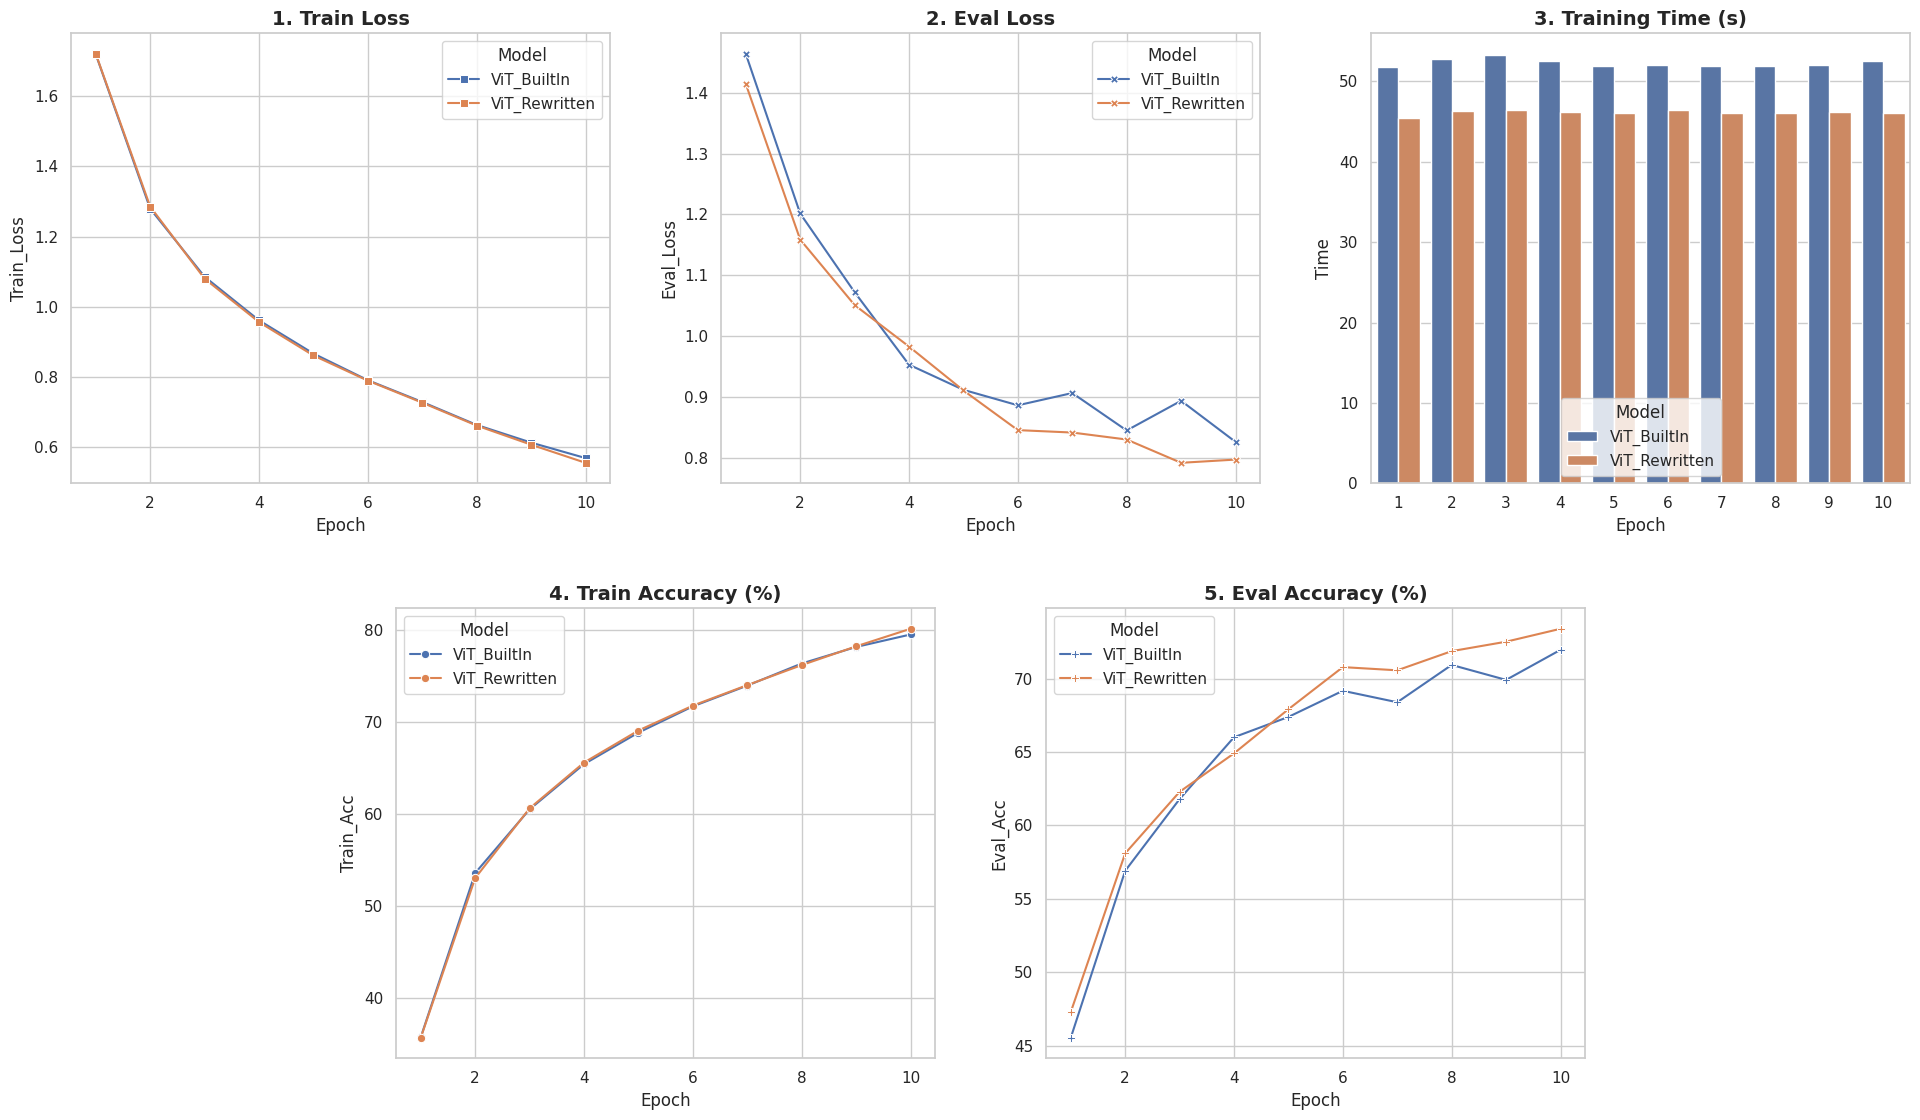

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_5_comparison_charts(histories):
    all_data = []

    for model_name, history in histories.items():
        num_epochs = len(history["train_loss"])
        for i in range(num_epochs):
            all_data.append({
                'Epoch': i + 1,
                'Train_Loss': history["train_loss"][i],
                'Train_Acc': history["train_acc"][i],
                'Eval_Loss': history["eval_loss"][i],
                'Eval_Acc': history["eval_acc"][i],
                'Time': history["time"][i],
                'Model': model_name
            })

    df = pd.DataFrame(all_data)

    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(20, 12))

    ax1 = plt.subplot2grid((2, 6), (0, 0), colspan=2)
    ax2 = plt.subplot2grid((2, 6), (0, 2), colspan=2)
    ax3 = plt.subplot2grid((2, 6), (0, 4), colspan=2)

    ax4 = plt.subplot2grid((2, 6), (1, 1), colspan=2)
    ax5 = plt.subplot2grid((2, 6), (1, 3), colspan=2)

    sns.lineplot(ax=ax1, data=df, x='Epoch', y='Train_Loss', hue='Model', marker='s')
    ax1.set_title('1. Train Loss', fontsize=14, fontweight='bold')

    sns.lineplot(ax=ax2, data=df, x='Epoch', y='Eval_Loss', hue='Model', marker='X')
    ax2.set_title('2. Eval Loss', fontsize=14, fontweight='bold')

    sns.barplot(ax=ax3, data=df, x='Epoch', y='Time', hue='Model')
    ax3.set_title('3. Training Time (s)', fontsize=14, fontweight='bold')

    sns.lineplot(ax=ax4, data=df, x='Epoch', y='Train_Acc', hue='Model', marker='o')
    ax4.set_title('4. Train Accuracy (%)', fontsize=14, fontweight='bold')

    sns.lineplot(ax=ax5, data=df, x='Epoch', y='Eval_Acc', hue='Model', marker='P')
    ax5.set_title('5. Eval Accuracy (%)', fontsize=14, fontweight='bold')

    plt.tight_layout(pad=3.0)
    plt.show()

combined_histories = {
    "ViT_BuiltIn": histories_trad["ViT_BuiltIn"],
    "ViT_Rewritten": histories_vitwrite["ViT_Rewritten"]
}

plot_5_comparison_charts(combined_histories)

#Part 4: Assemble Architecture and Different Image Embeddings

#Part 5: LSTM/GRU based Classification